# TFT Test Set Evaluation — Zaragoza NWP Forecast Model

This notebook evaluates the NWP-augmented TFT on the held-out test set (2025-07-01 to 2025-12-31)
and produces the **three-way comparison** for the Zaragoza experiment:

| Model | Weather in decoder | Expected R² |
|---|---|---|
| Standard (nb 4) | None | 0.8284 (known) |
| **NWP (this notebook)** | Open-Meteo ECMWF forecast | ? |
| Perfect forecast (nb 5b) | ERA5 as perfect forecast | ? |

The gap Standard → NWP shows the value of adding real forecast data.
The gap NWP → Perfect shows the cost of forecast imperfection vs. a perfect oracle.

The test set is touched **exactly once** here.

**Pipeline steps:**

| # | Step | Purpose |
|---|---|---|
| 0 | Imports & configuration | Load params from training notebook |
| 1 | Reconstruct dataset for test split | Continuous time_idx across all splits |
| 2 | Load model & generate predictions | Best checkpoint from 4c |
| 3 | Test metrics | RMSE, MAE, R², MASE |
| 4 | Baseline comparisons | Persistence, climatological |
| 5 | Visualizations | Time series, scatter, residuals, variable importance |
| 6 | Three-way comparison | Standard vs NWP vs Perfect forecast |

## Step 0 — Imports & configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# Patch torch.load to allow weights_only=False (safe for re-runs)
if not getattr(torch, '_orig_load', None):
    torch._orig_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return torch._orig_load(*args, **kwargs)
torch.load = _patched_torch_load

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

DATA_DIR   = os.path.join(os.getcwd(), 'data')
MODEL_DIR  = os.path.join(os.getcwd(), 'models', 'nwp_forecast')
PF_DIR     = os.path.join(os.getcwd(), 'models', 'perfect_forecast')
STD_DIR    = os.path.join(os.getcwd(), 'models')

MAX_ENCODER_LENGTH    = 168
MAX_PREDICTION_LENGTH = 24

KNOWN_FUTURE = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
    'ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast',
    'surface_pressure_hPa_forecast', 'total_precip_mm_forecast',
    'kt_forecast', 'dewpoint_depression_C_forecast',
]
OBSERVED = [
    'dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
    'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'kt', 'dewpoint_depression_C',
]
TARGET = 'pv_generation_mwh'

with open(os.path.join(DATA_DIR, 'nwp_preprocessing_params.json')) as f:
    pp = json.load(f)
TARGET_MEAN = pp['target_mean']
TARGET_STD  = pp['target_std']

with open(os.path.join(MODEL_DIR, 'nwp_hp_study_results.json')) as f:
    hp_results = json.load(f)

print(f"Best HPs from training: {hp_results['best_params']}")
print(f"Val metrics: {hp_results['val_metrics_mwh']}")
print(f"Target denorm: z * {TARGET_STD:.4f} + {TARGET_MEAN:.4f}")

c:\Users\nicol\Documents\ML-solar-forecast\.venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Best HPs from training: {'hidden_size': 64, 'lstm_layers': 2, 'attention_head_size': 2, 'dropout': 0.2560204063533433, 'hidden_continuous_size': 32, 'learning_rate': 0.0035503048581283078}
Val metrics: {'MAE_MWh': 85.12372277277804, 'RMSE_MWh': 161.62847853282386, 'R2': 0.8768840705584865, 'nRMSE_pct': 48.13543452344521}
Target denorm: z * 443.4560 + 335.7786


## Step 1 — Reconstruct dataset for test split

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'nwp_train_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'nwp_val_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'nwp_test_processed.csv'),
                        parse_dates=['datetime_utc'], index_col='datetime_utc').reset_index()

train_df['time_idx'] = np.arange(len(train_df))
val_df['time_idx']   = np.arange(len(train_df), len(train_df) + len(val_df))
test_df['time_idx']  = np.arange(len(train_df) + len(val_df),
                                   len(train_df) + len(val_df) + len(test_df))

for df in [train_df, val_df, test_df]:
    df['group_id'] = '0'

print(f"Train: {len(train_df):,} rows  time_idx [0, {train_df['time_idx'].max()}]")
print(f"Val:   {len(val_df):,} rows   time_idx [{val_df['time_idx'].min()}, {val_df['time_idx'].max()}]")
print(f"Test:  {len(test_df):,} rows  time_idx [{test_df['time_idx'].min()}, {test_df['time_idx'].max()}]")

Train: 17,544 rows  time_idx [0, 17543]
Val:   4,344 rows   time_idx [17544, 21887]
Test:  4,416 rows  time_idx [21888, 26303]


In [3]:
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target=TARGET,
    group_ids=['group_id'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    time_varying_known_reals=KNOWN_FUTURE,
    time_varying_unknown_reals=OBSERVED,
    target_normalizer=None,
    scalers={col: None for col in KNOWN_FUTURE + OBSERVED},
    add_relative_time_idx=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

test_with_context = pd.concat([
    val_df.iloc[-MAX_ENCODER_LENGTH:],
    test_df
], ignore_index=True)

test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, test_with_context, stop_randomization=True,
)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=64, num_workers=2)

print(f"Test dataset: {len(test_dataset)} samples")
assert len(test_dataset) > 100

Test dataset: 4393 samples


## Step 2 — Load model & generate predictions

In [4]:
def denormalize(z_values):
    return z_values * TARGET_STD + TARGET_MEAN

def compute_metrics(actual_mwh, predicted_mwh):
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    r2   = 1 - (residuals ** 2).sum() / ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    nrmse = (rmse / TARGET_MEAN) * 100  # normalized by train-set mean
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2), 'nRMSE_pct': float(nrmse)}

In [5]:
ckpt_path = os.path.join(MODEL_DIR, 'tft_nwp_best.ckpt')
best_model = TemporalFusionTransformer.load_from_checkpoint(ckpt_path)
best_model.eval()
print(f"Loaded model from {ckpt_path}")
print(f"Model parameters: {sum(p.numel() for p in best_model.parameters()):,}")

Loaded model from c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\nwp_forecast\tft_nwp_best.ckpt
Model parameters: 603,127


In [6]:
test_predictions = best_model.predict(
    test_dataloader, mode='prediction', return_x=True, return_y=True,
)
test_raw = best_model.predict(test_dataloader, mode='raw', return_x=True)

# Extract prediction windows (n_windows, 24)
pred_z   = test_predictions.output.cpu().numpy()
actual_z = test_predictions.y[0].cpu().numpy()

# ── Per-timestep aggregation ──
# The TFT produces overlapping 24h windows: window i predicts hours [i, i+23].
# Each test hour gets predicted by up to 24 different windows at different horizons.
# We average all predictions for each timestep to get one prediction per hour,
# ensuring metrics are computed on the same basis as XGBoost (one pred per hour).
n_test = len(test_df)
agg_sum = np.zeros(n_test)
agg_count = np.zeros(n_test)
n_windows = pred_z.shape[0]
for i in range(n_windows):
    for h in range(MAX_PREDICTION_LENGTH):
        t = i + h
        if t < n_test:
            agg_sum[t] += pred_z[i, h]
            agg_count[t] += 1
mask = agg_count > 0
pred_z_agg = np.zeros(n_test)
pred_z_agg[mask] = agg_sum[mask] / agg_count[mask]

pred_mwh   = np.clip(denormalize(pred_z_agg), 0, None)
actual_mwh = denormalize(test_df[TARGET].values)

print(f"Prediction windows: {pred_z.shape[0]}")
print(f"Per-timestep predictions: {mask.sum()} unique test hours")
print(f"  (avg {agg_count[mask].mean():.1f} overlapping windows per hour)")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU co

Prediction windows: 4393
Per-timestep predictions: 4416 unique test hours
  (avg 23.9 overlapping windows per hour)


## Step 3 — Test metrics

In [7]:
test_metrics = compute_metrics(actual_mwh, pred_mwh)

test_gen = denormalize(test_df[TARGET].values)
persistence_mae = np.abs(test_gen[24:] - test_gen[:-24]).mean()
mase = test_metrics['MAE_MWh'] / persistence_mae

print("=" * 60)
print("TEST SET METRICS — NWP Model (original MWh scale)")
print("=" * 60)
print(f"  RMSE:  {test_metrics['RMSE_MWh']:.2f} MWh")
print(f"  MAE:   {test_metrics['MAE_MWh']:.2f} MWh")
print(f"  R²:    {test_metrics['R2']:.4f}")
print(f"  MASE:  {mase:.4f}")
print("=" * 60)

TEST SET METRICS — NWP Model (original MWh scale)
  RMSE:  160.62 MWh
  MAE:   86.88 MWh
  R²:    0.8969
  MASE:  0.7474


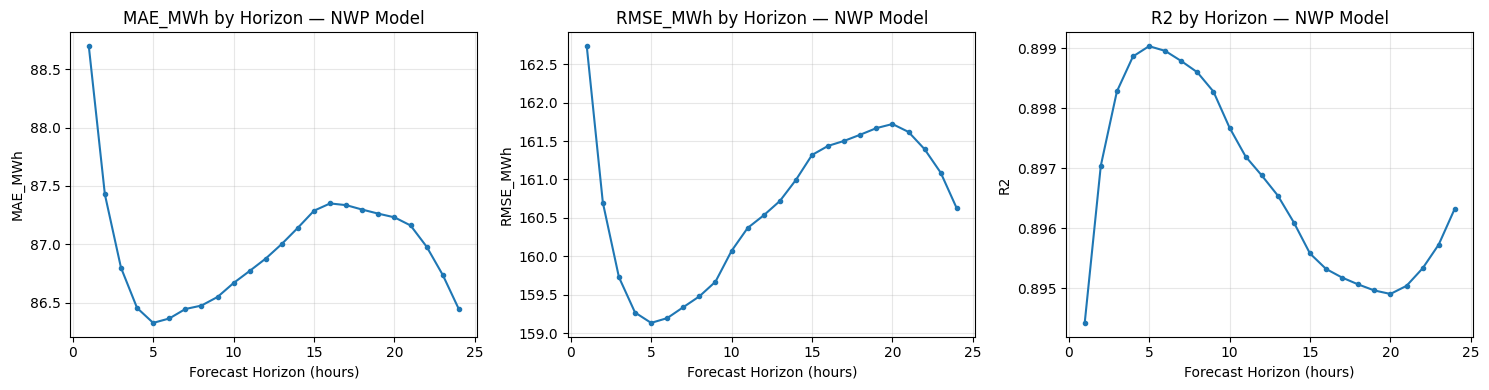

In [8]:
# Per-horizon metrics
horizon_metrics = []
for h in range(MAX_PREDICTION_LENGTH):
    pred_h   = np.clip(denormalize(pred_z[:, h]), 0, None)
    actual_h = denormalize(actual_z[:, h])
    m = compute_metrics(actual_h, pred_h)
    m['horizon_h'] = h + 1
    horizon_metrics.append(m)

horizon_df = pd.DataFrame(horizon_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE_MWh', 'RMSE_MWh', 'R2']):
    ax.plot(horizon_df['horizon_h'], horizon_df[metric], marker='o', markersize=3)
    ax.set_xlabel('Forecast Horizon (hours)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Horizon — NWP Model')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Baseline comparisons

In [9]:
# Persistence
persistence_pred    = test_gen[:-24]
persistence_actual  = test_gen[24:]
persistence_metrics = compute_metrics(persistence_actual, persistence_pred)

# Climatological
train_gen_mwh = denormalize(train_df[TARGET].values)
train_hours   = pd.to_datetime(train_df['datetime_utc']).dt.hour
hourly_means  = pd.Series(train_gen_mwh, index=train_hours.values).groupby(level=0).mean()
test_hours    = pd.to_datetime(test_df['datetime_utc']).dt.hour.values
clim_pred     = hourly_means.loc[test_hours].values
clim_metrics  = compute_metrics(test_gen, clim_pred)

print(f"\n{'Model':<25s} {'RMSE (MWh)':>12s} {'MAE (MWh)':>12s} {'R²':>8s}")
print("-" * 60)
print(f"{'TFT NWP (ours)':<25s} {test_metrics['RMSE_MWh']:12.2f} {test_metrics['MAE_MWh']:12.2f} {test_metrics['R2']:8.4f}")
print(f"{'Persistence (24h)':<25s} {persistence_metrics['RMSE_MWh']:12.2f} {persistence_metrics['MAE_MWh']:12.2f} {persistence_metrics['R2']:8.4f}")
print(f"{'Climatological':<25s} {clim_metrics['RMSE_MWh']:12.2f} {clim_metrics['MAE_MWh']:12.2f} {clim_metrics['R2']:8.4f}")


Model                       RMSE (MWh)    MAE (MWh)       R²
------------------------------------------------------------
TFT NWP (ours)                  160.62        86.88   0.8969
Persistence (24h)               236.37       116.24   0.7755
Climatological                  279.57       173.41   0.6878


## Step 5 — Visualizations

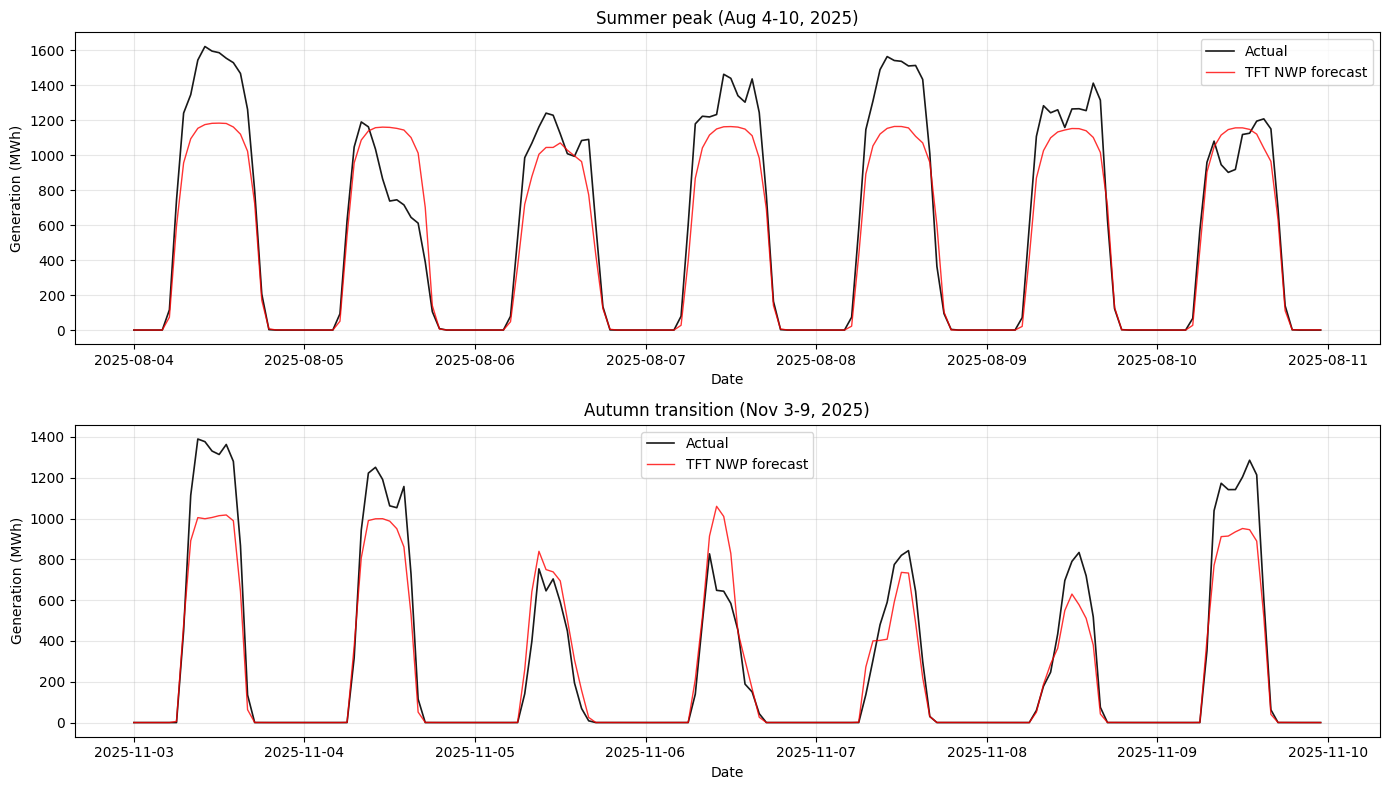

In [10]:
# 5a: Day-ahead time series — selected test weeks
test_datetime = pd.to_datetime(test_df['datetime_utc'])
n_windows = pred_z.shape[0]

dayahead_pred   = {}
dayahead_actual = {}
for i in range(n_windows):
    ts = test_datetime.iloc[i]
    if ts.hour == 0:
        for h in range(MAX_PREDICTION_LENGTH):
            idx = i + h
            if idx < len(test_df):
                t = test_datetime.iloc[idx]
                dayahead_pred[t]   = np.clip(denormalize(pred_z[i, h]), 0, None)
                dayahead_actual[t] = denormalize(test_df[TARGET].iloc[idx])

pred_series   = pd.Series(dayahead_pred)
actual_series = pd.Series(dayahead_actual)

week_starts = [
    ('Summer peak (Aug 4-10, 2025)', '2025-08-04', '2025-08-10'),
    ('Autumn transition (Nov 3-9, 2025)', '2025-11-03', '2025-11-09'),
]

fig, axes = plt.subplots(len(week_starts), 1, figsize=(14, 4 * len(week_starts)))
for ax, (title, start, end) in zip(axes, week_starts):
    end_ts = end + ' 23:00:00'
    ax.plot(actual_series[start:end_ts].index, actual_series[start:end_ts].values,
            'k-', linewidth=1.2, label='Actual', alpha=0.9)
    ax.plot(pred_series[start:end_ts].index, pred_series[start:end_ts].values,
            'r-', linewidth=1.0, label='TFT NWP forecast', alpha=0.8)
    ax.set_xlabel('Date')
    ax.set_ylabel('Generation (MWh)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

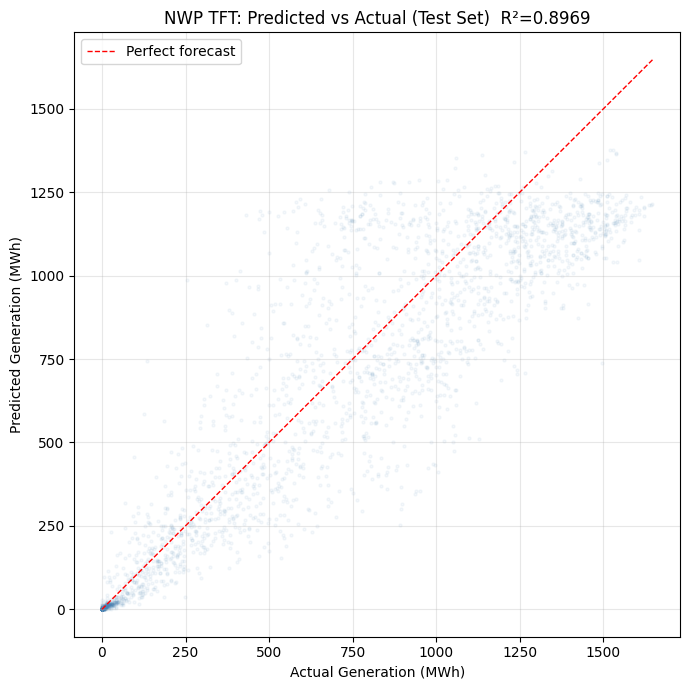

In [11]:
# 5b: Scatter
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual_mwh, pred_mwh, alpha=0.05, s=5, c='steelblue')
max_val = max(actual_mwh.max(), pred_mwh.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect forecast')
ax.set_xlabel('Actual Generation (MWh)')
ax.set_ylabel('Predicted Generation (MWh)')
ax.set_title(f'NWP TFT: Predicted vs Actual (Test Set)  R²={test_metrics["R2"]:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

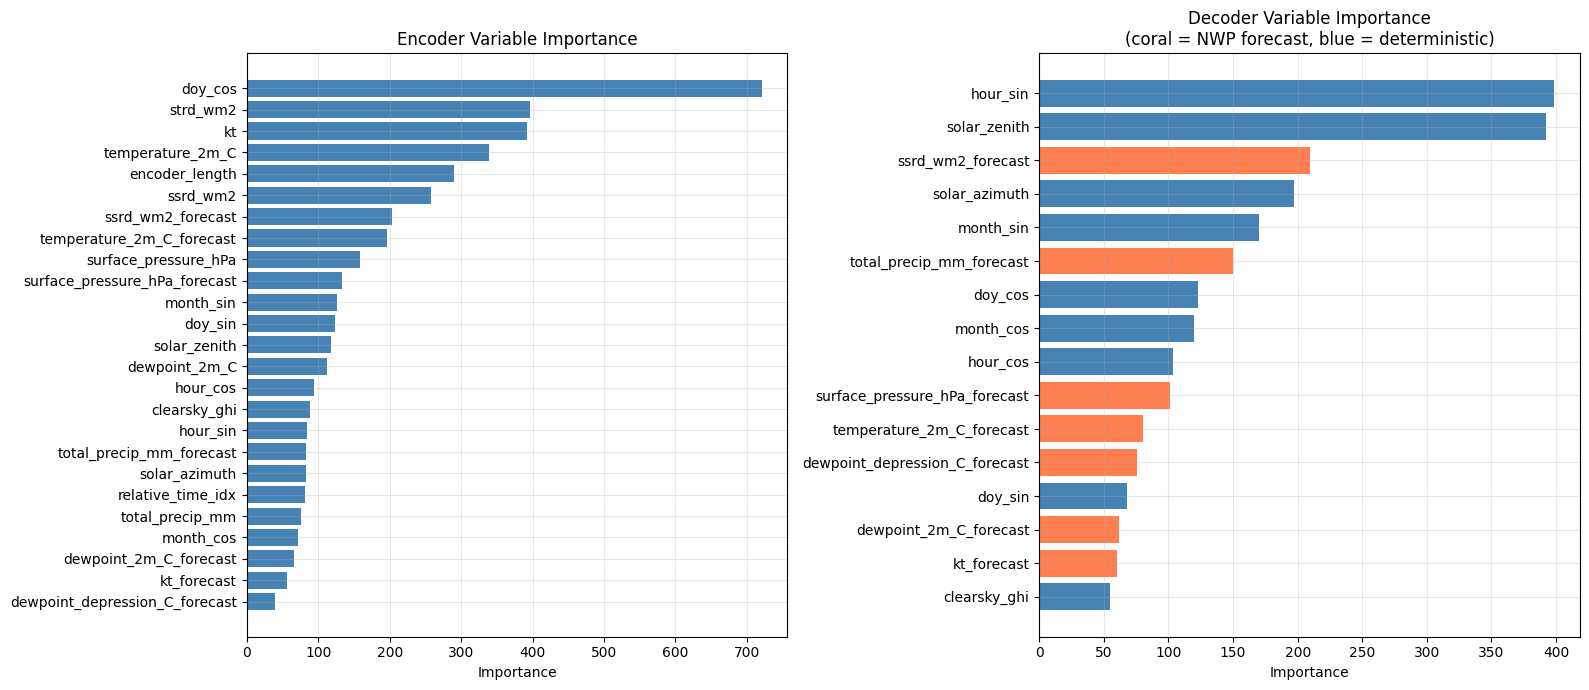

In [12]:
# 5c: Variable importance
interpretation = best_model.interpret_output(test_raw.output, reduction='sum')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

enc_vars = training_dataset.reals
enc_imp  = interpretation['encoder_variables'].cpu().numpy()
enc_sorted = sorted(zip(enc_vars, enc_imp), key=lambda x: x[1], reverse=True)
enc_names, enc_vals = zip(*enc_sorted)
axes[0].barh(range(len(enc_names)), enc_vals, color='steelblue')
axes[0].set_yticks(range(len(enc_names)))
axes[0].set_yticklabels(enc_names)
axes[0].set_xlabel('Importance')
axes[0].set_title('Encoder Variable Importance')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

# Decoder shows both calendar/geometry AND forecast variables — the key question
# is whether forecast variables rank highly vs. calendar features.
dec_vars = list(training_dataset.time_varying_known_reals)
dec_imp  = interpretation['decoder_variables'].cpu().numpy()
dec_sorted = sorted(zip(dec_vars, dec_imp), key=lambda x: x[1], reverse=True)
dec_names, dec_vals = zip(*dec_sorted)
colors = ['coral' if '_forecast' in n else 'steelblue' for n in dec_names]
axes[1].barh(range(len(dec_names)), dec_vals, color=colors)
axes[1].set_yticks(range(len(dec_names)))
axes[1].set_yticklabels(dec_names)
axes[1].set_xlabel('Importance')
axes[1].set_title('Decoder Variable Importance\n(coral = NWP forecast, blue = deterministic)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Three-way comparison

Loads results from the standard model (notebook 5) and perfect forecast model (notebook 5b)
if available, and produces the final comparison table.

In [13]:
results = {}

# ── Standard model (notebook 4/5) ──
standard_results_path = os.path.join(STD_DIR, 'hp_study_results.json')
if os.path.exists(standard_results_path):
    with open(standard_results_path) as f:
        std = json.load(f)
    results['Standard (no NWP)'] = std.get('test_metrics_mwh', std.get('val_metrics_mwh', {}))
else:
    results['Standard (no NWP)'] = {'R2': 0.8284, 'RMSE_MWh': 295.61, 'MAE_MWh': 152.00}

# ── NWP model (this notebook) ──
results['NWP (Open-Meteo)'] = test_metrics

# ── Perfect forecast model (notebook 5b) ──
pf_results_path = os.path.join(PF_DIR, 'hp_study_results_pf.json')
if os.path.exists(pf_results_path):
    with open(pf_results_path) as f:
        pf = json.load(f)
    results['Perfect forecast (ERA5)'] = pf.get('test_metrics_mwh', pf.get('val_metrics_mwh', {}))
else:
    results['Perfect forecast (ERA5)'] = {'R2': None, 'RMSE_MWh': None, 'MAE_MWh': None,
                                           'note': 'run 5b to populate'}

print("=" * 70)
print("THREE-WAY COMPARISON — Zaragoza TFT Solar Forecast (Test Set)")
print("=" * 70)
print(f"\n{'Model':<30s} {'RMSE (MWh)':>12s} {'MAE (MWh)':>12s} {'R²':>8s}")
print("-" * 65)
for model_name, m in results.items():
    rmse = f"{m['RMSE_MWh']:.2f}" if m.get('RMSE_MWh') is not None else '—'
    mae  = f"{m['MAE_MWh']:.2f}"  if m.get('MAE_MWh')  is not None else '—'
    r2   = f"{m['R2']:.4f}"       if m.get('R2')        is not None else '—'
    print(f"{model_name:<30s} {rmse:>12s} {mae:>12s} {r2:>8s}")

print("\n" + "=" * 70)
nwp_r2 = test_metrics['R2']
std_r2 = results['Standard (no NWP)']['R2']
pf_r2  = results['Perfect forecast (ERA5)'].get('R2')
if std_r2:
    print(f"\nNWP vs Standard:        ΔR² = {nwp_r2 - std_r2:+.4f}")
if pf_r2:
    print(f"Perfect vs NWP:         ΔR² = {pf_r2 - nwp_r2:+.4f}")
    print(f"Perfect vs Standard:    ΔR² = {pf_r2 - std_r2:+.4f}")

THREE-WAY COMPARISON — Zaragoza TFT Solar Forecast (Test Set)

Model                            RMSE (MWh)    MAE (MWh)       R²
-----------------------------------------------------------------
Standard (no NWP)                    295.61       152.00   0.8284
NWP (Open-Meteo)                     160.62        86.88   0.8969
Perfect forecast (ERA5)              163.29        87.32   0.8935


NWP vs Standard:        ΔR² = +0.0685
Perfect vs NWP:         ΔR² = -0.0034
Perfect vs Standard:    ΔR² = +0.0651


In [14]:
# Save test metrics back to nwp_hp_study_results.json
nwp_json_path = os.path.join(MODEL_DIR, 'nwp_hp_study_results.json')
with open(nwp_json_path) as f:
    nwp_data = json.load(f)
nwp_data['test_metrics_mwh'] = {
    'MAE_MWh':  test_metrics['MAE_MWh'],
    'RMSE_MWh': test_metrics['RMSE_MWh'],
    'R2':       test_metrics['R2'],
}
with open(nwp_json_path, 'w') as f:
    json.dump(nwp_data, f, indent=2)
print(f'Saved test_metrics_mwh to {nwp_json_path}')

Saved test_metrics_mwh to c:\Users\nicol\Documents\ML-solar-forecast\zaragoza\models\nwp_forecast\nwp_hp_study_results.json


In [15]:
# Free GPU memory before moving to next notebook
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print("GPU memory released.")

GPU memory released.
